In [1]:
import cleanup
import plotting
import stat_analysis
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sbs
import math as math
import os
from os import listdir
import tkinter
from tkinter import filedialog
import scipy as scp
import scipy.stats as scpst
import framewise_stats

pd.options.mode.use_inf_as_na = True

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\cleanup.py:13: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True
C:\Users\hpnhp\AppData\Local\Temp\ipykernel_28448\4179930702.py:20: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True


In [11]:
tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()
primary_df = cleanup.data_to_dataframe(filepath)

In [12]:
primary_df = primary_df[primary_df['Frame']<600]
primary_df = cleanup.calculate_distance_from_fixed_point(primary_df)
primary_df = cleanup.categorize_values(primary_df, 'X', 14, 1.5)

primary_df_interp = cleanup.interpolate_missing_values(primary_df)
primary_df_interp = cleanup.calculate_distance_from_fixed_point(primary_df_interp)

In [ ]:
# df_WT_Trh = primary_df_interp[(primary_df_interp['Genotype'] == 'WT') |
#                               (primary_df_interp['Genotype'] == 'Trh')]
# df_WT_Trh_EA = df_WT_Trh[df_WT_Trh['Odour'] == 'EA']
# df_WT_Trh_PA = df_WT_Trh[df_WT_Trh['Odour'] == 'PA']
# df_WT_Trh_1P = df_WT_Trh[df_WT_Trh['Odour'] == '1P']

# df_Kir_CSD_Trh = primary_df_interp[(primary_df_interp['Genotype'] == 'WTxKir') 
#                                  | (primary_df_interp['Genotype'] == 'TrhxKir')
#                                  | (primary_df_interp['Genotype'] == 'CSDxKir')
#                                  | (primary_df_interp['Genotype'] == 'WTxCSD')
#                                  | (primary_df_interp['Genotype'] == 'WTxTrh')]
# df_Kir_CSD_Trh = df_Kir_CSD_Trh[(df_Kir_CSD_Trh['Starvation'] == 'Fed')
#                               | (df_Kir_CSD_Trh['Starvation'] == '5h')]
# df_Kir_CSD_Trh_EA = df_Kir_CSD_Trh[df_Kir_CSD_Trh['Odour'] == 'EA']
# df_Kir_CSD_Trh_PA = df_Kir_CSD_Trh[df_Kir_CSD_Trh['Odour'] == 'PA']
# df_Kir_CSD_Trh_1P = df_Kir_CSD_Trh[df_Kir_CSD_Trh['Odour'] == '1P']

# df_Kir_CSD = df_Kir_CSD_Trh[(df_Kir_CSD_Trh['Genotype'] == 'WTxCSD')
#                         | (df_Kir_CSD_Trh['Genotype'] == 'WTxKir')
#                         | (df_Kir_CSD_Trh['Genotype'] == 'CSDxKir')]
# df_Kir_CSD_EA = df_Kir_CSD[df_Kir_CSD['Odour'] == 'EA']

# df_TNT_uPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexUPN')
#                             |  (primary_df_interp['Genotype'] == 'TNTixUPN')]

# df_TNT_MPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexMPN')
#                             |  (primary_df_interp['Genotype'] == 'TNTixMPN')]

# df_TNT_5HT1A = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT1A')
#                             |    (primary_df_interp['Genotype'] == 'TNTix5HT1A')]

# df_TNT_5HT7 = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT7')
#                             |   (primary_df_interp['Genotype'] == 'TNTix5HT7')]

In [13]:
# WT and Trh dataframes for PA and 1P 
df_WT_Trh = primary_df_interp[(primary_df_interp['Genotype'] == 'WT') 
                            | (primary_df_interp['Genotype'] == 'TRH')]


df_WT_Trh_PA = df_WT_Trh[df_WT_Trh['Odour'] == 'PA']
df_WT_Trh_1P = df_WT_Trh[df_WT_Trh['Odour'] == '1-P']


df_WT_PA = df_WT_Trh_PA[(df_WT_Trh_PA['Genotype'] == 'WT')]
df_Trh_PA = df_WT_Trh_PA[(df_WT_Trh_PA['Genotype'] == 'TRH')]

df_WT_PA_104 = df_WT_PA[df_WT_PA['Concentration'] == '10-4']
df_Trh_PA_104 = df_Trh_PA[df_Trh_PA['Concentration'] == '10-4']



df_WT_1P = df_WT_Trh_1P[(df_WT_Trh_1P['Genotype'] == 'WT')]
df_Trh_1P = df_WT_Trh_1P[(df_WT_Trh_1P['Genotype'] == 'TRH')]   

df_WT_1P_102 = df_WT_1P[df_WT_1P['Concentration'] == '10-2']
df_Trh_1P_102 = df_Trh_1P[df_Trh_1P['Concentration'] == '10-2']


#Kir crosses for PA and 1P 

df_KirCross = primary_df_interp[(primary_df_interp['Genotype'] == 'WTxKIR')
                                | (primary_df_interp['Genotype'] == 'TRHxKIR')
                                | (primary_df_interp['Genotype'] == 'CSDxKIR')
                                | (primary_df_interp['Genotype'] == 'WTxCSD')
                                | (primary_df_interp['Genotype'] == 'WTxTRH')]

df_KirCross_PA = df_KirCross[df_KirCross['Odour'] == 'PA']
df_KirCross_1P = df_KirCross[df_KirCross['Odour'] == '1-P']


df_KirCross_PA_CSD = df_KirCross_PA[(df_KirCross_PA['Genotype'] == 'WTxCSD')
                                    | (df_KirCross_PA['Genotype'] == 'CSDxKIR')
                                    | (df_KirCross_PA['Genotype'] == 'WTxKIR')]

df_KirCross_PA_TRH = df_KirCross_PA[(df_KirCross_PA['Genotype'] == 'WTxTRH')
                                    | (df_KirCross_PA['Genotype'] == 'TRHxKIR')
                                    | (df_KirCross_PA['Genotype'] == 'WTxKIR')]


df_KirCross_1P_CSD = df_KirCross_1P[(df_KirCross_1P['Genotype'] == 'WTxCSD')
                                    | (df_KirCross_1P['Genotype'] == 'CSDxKIR')
                                    | (df_KirCross_1P['Genotype'] == 'WTxKIR')]     

df_KirCross_1P_TRH = df_KirCross_1P[(df_KirCross_1P['Genotype'] == 'WTxTRH')
                                    | (df_KirCross_1P['Genotype'] == 'TRHxKIR')
                                    | (df_KirCross_1P['Genotype'] == 'WTxKIR')]



#Concentration validation --> EA

df_KirCross_EA = df_KirCross[df_KirCross['Odour'] == 'EA']

df_KirCross_EA_fed_5h = df_KirCross_EA[(df_KirCross_EA['Starvation'] == 'Fed')
                                      | (df_KirCross_EA['Starvation'] == '5h')]

df_WTxKir_EA_fed_5h = df_KirCross_EA_fed_5h[df_KirCross_EA_fed_5h['Genotype'] == 'WTxKIR']

df_WTxKir_EA_fed_5h_104_105 = df_WTxKir_EA_fed_5h[(df_WTxKir_EA_fed_5h['Concentration'] == '10-4')
                                                    | (df_WTxKir_EA_fed_5h['Concentration'] == '10-5')]



#starvation effects on WT and WTxKir crosses --> EA

df_EA = primary_df_interp[(primary_df_interp['Odour'] == 'EA')]
df_EA_105 = df_EA[(df_EA['Concentration'] == '10-5')]


df_EA_105_starvation = df_EA_105[(df_EA_105['Genotype'] == 'WT')
                             | (df_EA_105['Genotype'] == 'WTxKIR')]


# HT Kir crosses for EA

df_KirCross_HT = primary_df_interp[(primary_df_interp['Genotype'] == 'WTxKIR')
                                | (primary_df_interp['Genotype'] == 'WTx5HT7')
                                | (primary_df_interp['Genotype'] == 'WTx5HT1A') 
                                | (primary_df_interp['Genotype'] == '5HT7xKIR')
                                | (primary_df_interp['Genotype'] == '5HT1AxKIR')]

df_KirCross_HT_EA = df_KirCross_HT[df_KirCross_HT['Odour'] == 'EA']
df_KirCross_HT_EA_105 = df_KirCross_HT_EA[(df_KirCross_HT_EA['Concentration'] == '10-5')
                                          &((df_KirCross_HT_EA['Starvation'] == 'Fed')
                                            | (df_KirCross_HT_EA['Starvation'] == '5h'))]

df_KirCross_5HT7_EA_105 = df_KirCross_HT_EA_105[(df_KirCross_HT_EA_105['Genotype'] == 'WTx5HT7')
                                                | (df_KirCross_HT_EA_105['Genotype'] == '5HT7xKIR')
                                                | (df_KirCross_HT_EA_105['Genotype'] == 'WTxKIR')]
df_KirCross_5HT1A_EA_105 = df_KirCross_HT_EA_105[(df_KirCross_HT_EA_105['Genotype'] == 'WTx5HT1A')
                                                | (df_KirCross_HT_EA_105['Genotype'] == '5HT1AxKIR')
                                                | (df_KirCross_HT_EA_105['Genotype'] == 'WTxKIR')]

# uPN

df_TNTxuPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexUPN')
                            | (primary_df_interp['Genotype'] == 'TNTixUPN')
                            | (primary_df_interp['Genotype'] == 'TNTexuPN')
                            | (primary_df_interp['Genotype'] == 'TNTixuPN')]

df_TNTxuPN_EA_105 = df_TNTxuPN[(df_TNTxuPN['Odour'] == 'EA')
                               & (df_TNTxuPN['Concentration'] == '10-5')]

df_TNTxuPN_EA_103 = df_TNTxuPN[(df_TNTxuPN['Odour'] == 'EA')
                               & (df_TNTxuPN['Concentration'] == '10-3')]

#mPN

df_TNTxMPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexMPN')
                            | (primary_df_interp['Genotype'] == 'TNTixMPN')]

df_TNTxMPN_EA_105 = df_TNTxMPN[(df_TNTxMPN['Odour'] == 'EA')
                               & (df_TNTxMPN['Concentration'] == '10-5')]

# TNTx5HT7

df_TNTx5HT7 = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT7')
                            | (primary_df_interp['Genotype'] == 'TNTix5HT7')]

df_TNTx5HT7_EA_105 = df_TNTx5HT7[(df_TNTx5HT7['Odour'] == 'EA')
                               & (df_TNTx5HT7['Concentration'] == '10-5')]

df_TNTx5HT7_EA_103 = df_TNTx5HT7[(df_TNTx5HT7['Odour'] == 'EA')
                               & (df_TNTx5HT7['Concentration'] == '10-3')]


# TNTx5HT1A
df_TNTx5HT1A = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT1A')
                            | (primary_df_interp['Genotype'] == 'TNTix5HT1A')]

df_TNTx5HT1A_EA_105 = df_TNTx5HT1A[(df_TNTx5HT1A['Odour'] == 'EA')
                               & (df_TNTx5HT1A['Concentration'] == '10-5')]

df_TNTx5HT1A_EA_103 = df_TNTx5HT1A[(df_TNTx5HT1A['Odour'] == 'EA')
                               & (df_TNTx5HT1A['Concentration'] == '10-3')] 

 

In [ ]:
# df_TNTxuPN[(df_TNTxuPN['Odour'] == 'EA') & (df_TNTxuPN['Concentration'] == '10-5')]

In [ ]:
# # Defining dataframes for framewise stats:

# frame_df = primary_df_interp[primary_df_interp['Starvation'] == 'Fed']
# frame_df = frame_df[frame_df['Frame'] > 300] 
# frame_df = frame_df[frame_df['Frame'] < 500] 


# # framewise_stats.analyze_two_way_anova(frame_df, plot = True, plot_transform=True)

In [ ]:
# framewise_stats.analyze_two_way_anova_permutation(frame_df, plot=True, plot_perm_dists=True)

In [ ]:
# import bayesian

# df_individual = (
#     frame_df.groupby(["Condition", "Trial", "Individual", "Genotype", "Starvation"], as_index=False)
#       ["Preference Index"].mean()
# )
# df_individual = df_individual.rename(columns={"Preference Index": "Preference_Index"})

In [ ]:
# results = bayesian.fit_bayesian_pi_model(df_individual)

In [ ]:
# framewise_stats.pairwise_tests_plot(frame_df, trial_averages=True, test="mannwhitney")

In [22]:
frame_df = primary_df_interp[primary_df_interp['Genotype'] == 'WT']
frame_df = frame_df[frame_df['Odour'] == 'PA']
# frame_df = frame_df[frame_df['Starvation'] == '5h']

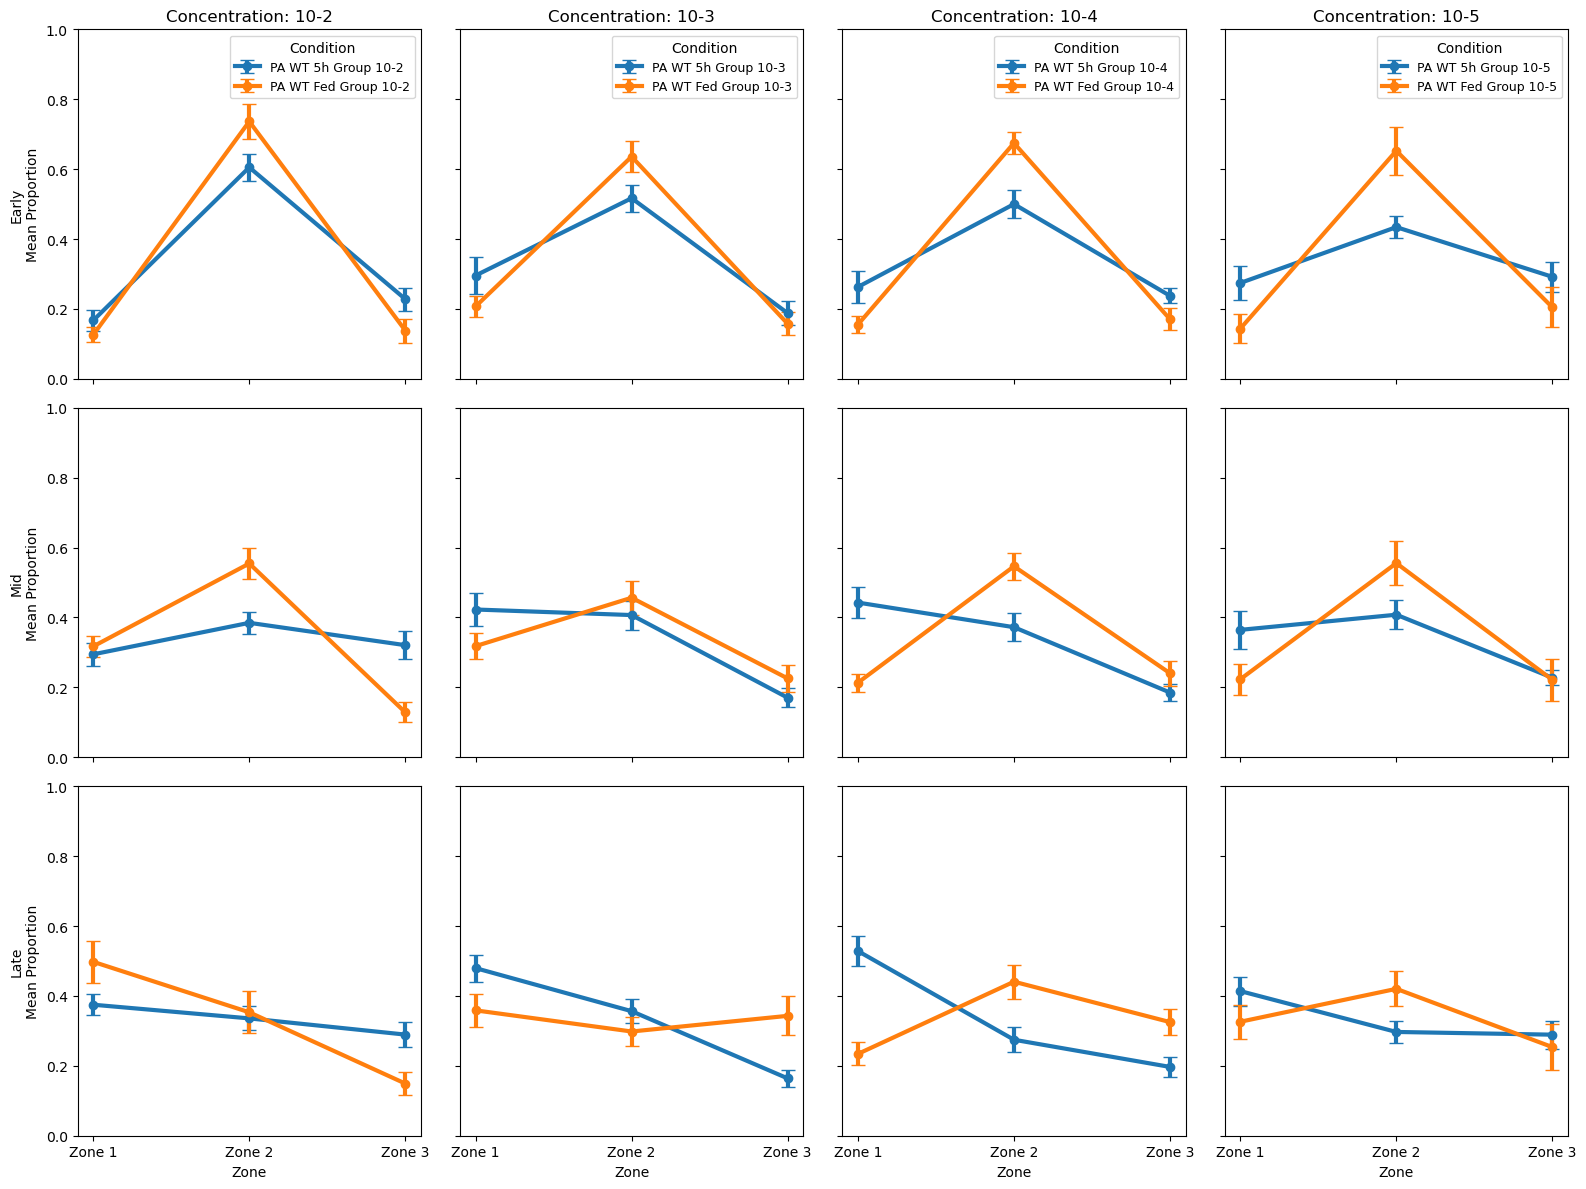

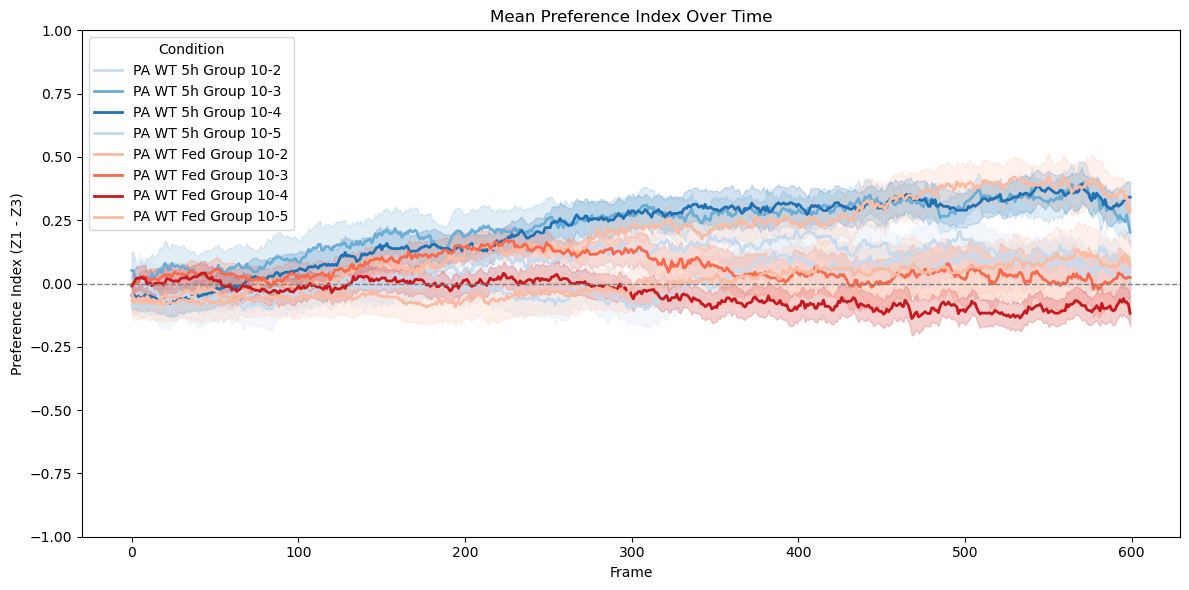

In [23]:
# #Replace the RHS with whichever dataframe you would like to plot.

df_plotter = frame_df

# #Comment or uncomment as and when plot is required.

#sbs.lineplot(df_plotter, x = 'Frame', y ='Distance', hue = 'Condition')

 # How to use the colour defining feature on all functions:
        # # Using a dict
        # custom_colors = {
        #     "ConditionA": "#1f77b4",  # blue
        #     "ConditionB": "#ff7f0e",  # orange
        #     "ConditionC": "#2ca02c",  # green
        #     "ConditionD": "#d62728"   # red
        # }

        # plot_zone_means_subplot(df, condition_colors=custom_colors)

        # # Or using a list (order = first appearance of conditions in the data)

        # plot_zone_means_subplot(df, condition_colors=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])

plotting.plot_zone_means_subplot_sem(df_plotter, condition_colors=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d62728", "#d62728"])

#plotting.plot_distance_by_condition(df_plotter, condition_colors=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d62728", "#d62728"])

#plotting.plot_preference_index_over_time(df_plotter, condition_colors=["#0765a8", "#52a4e7", "#23c4e8", "#e86f06", "#eba646", "#f3dc7e"])
plotting.plot_preference_index_over_time(df_plotter)

# for cond in df_plotter['Condition'].unique():
#     plotting.radial_sholl_heatmap_per_bin_normalized(df_plotter[df_plotter['Condition'] == cond], max_radius=11, spatial_bin=2)
#     plotting.plot_trajectory_heatmaps(df_plotter, cond) 

# plotting.plot_preference_index_boxplots(df_plotter, condition_colors=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d62728", "#d62728"])

# cumulative_df = plotting.analyze_and_plot_target_acquisition(df_plotter, condition_colors=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d62728", "#d62728"])

# params = plotting.fit_logistic_to_success(cumulative_df)

#params

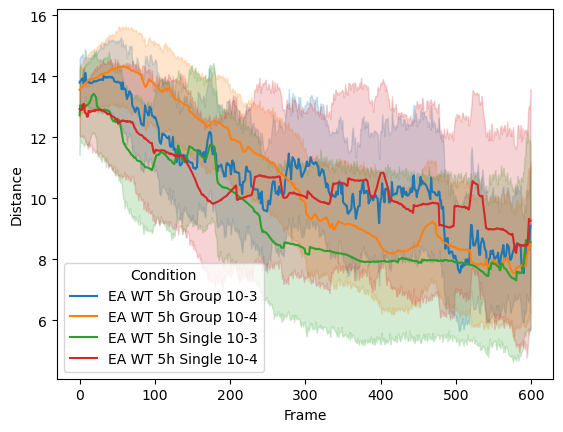

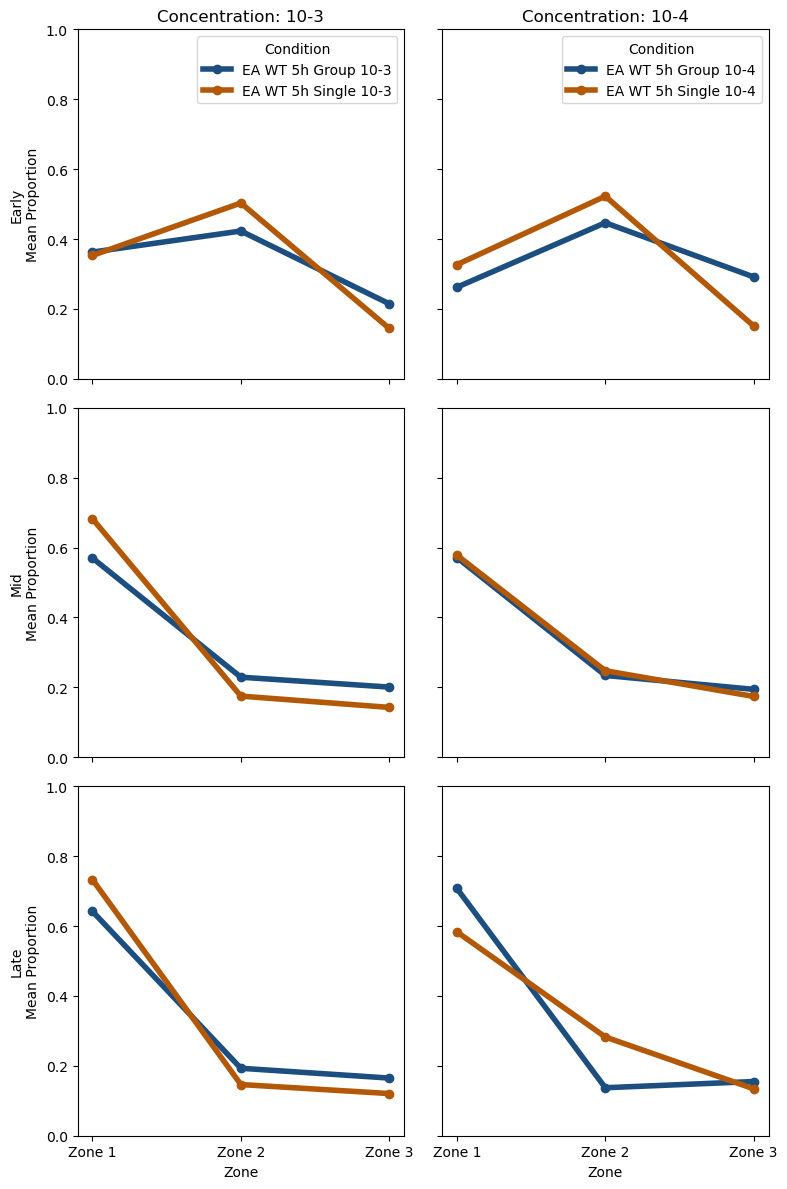

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:355: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Bin'] = (df[frame_column] // bin_size) * bin_size


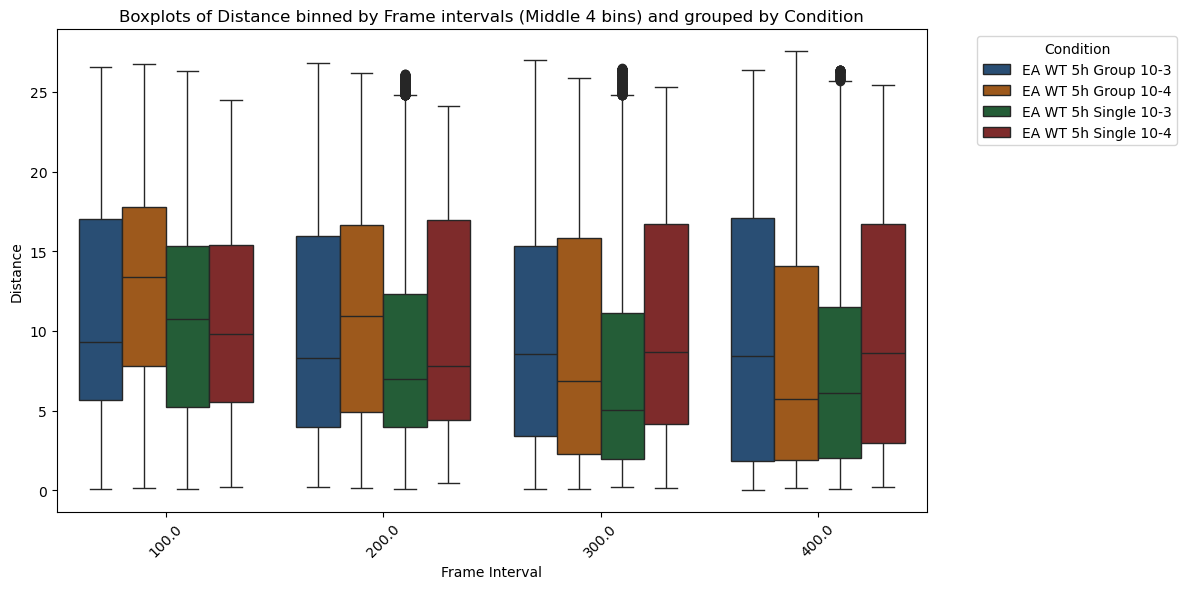

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:1151: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


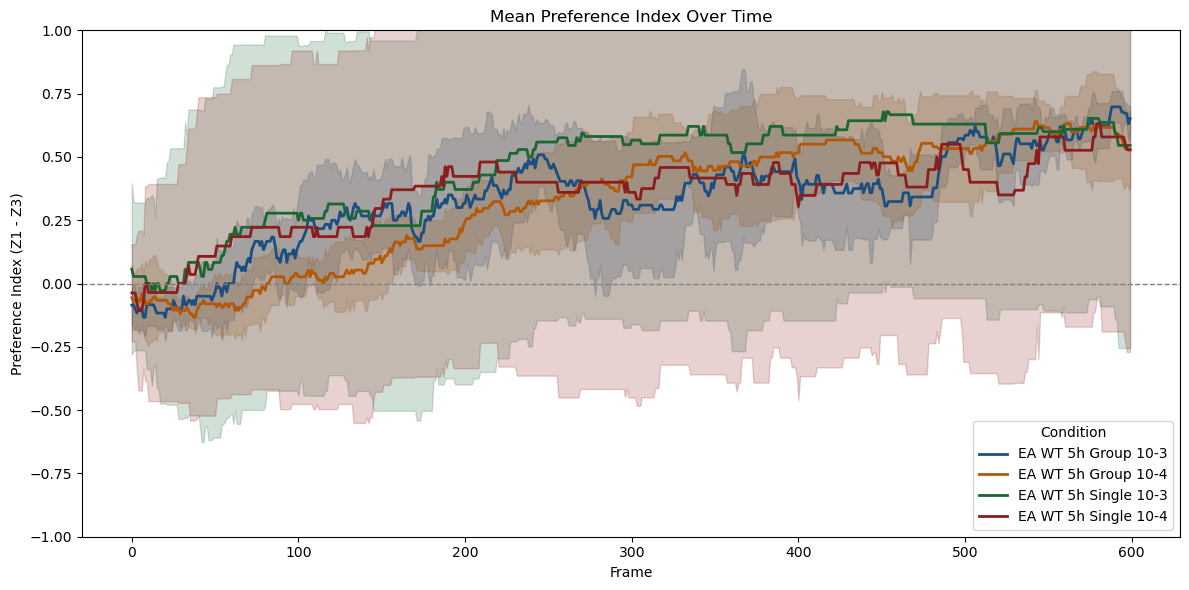

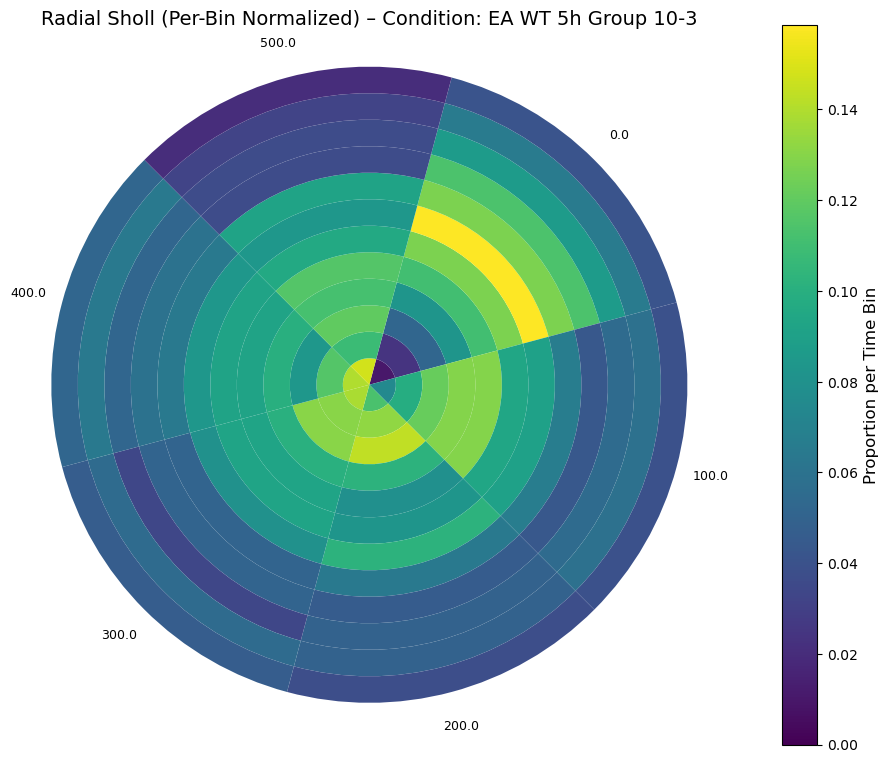

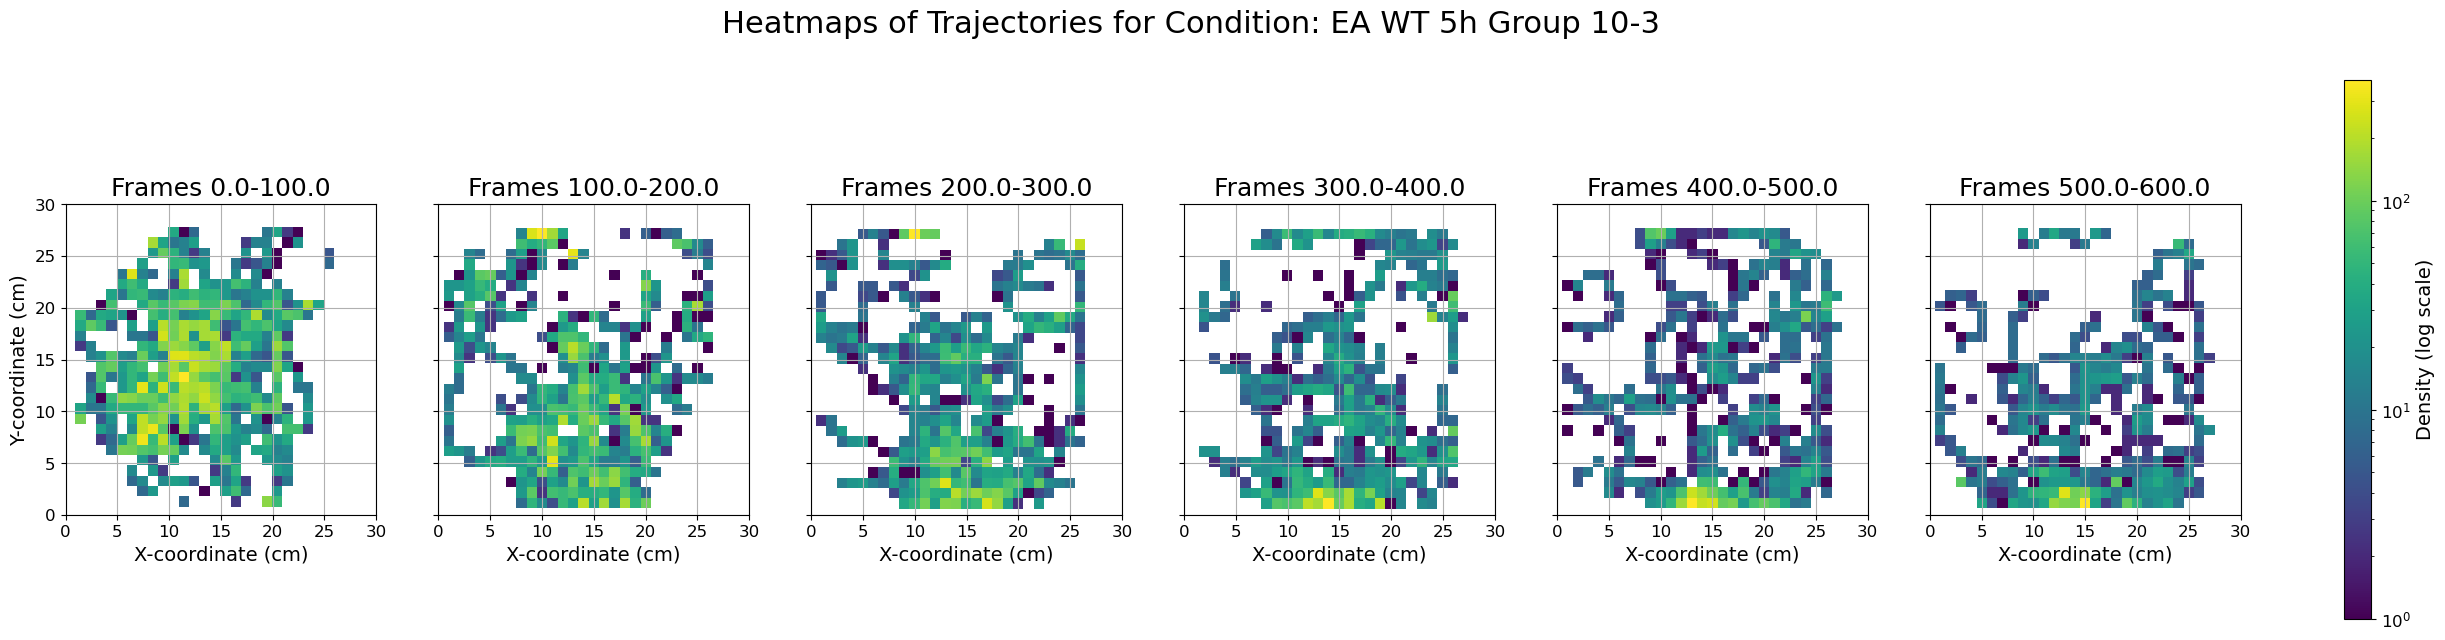

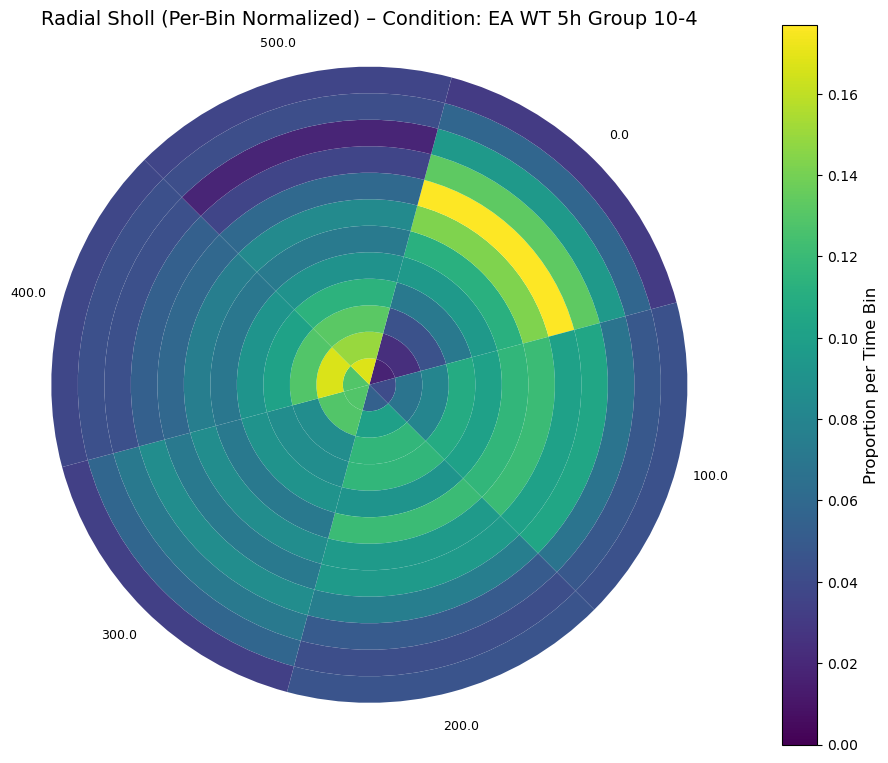

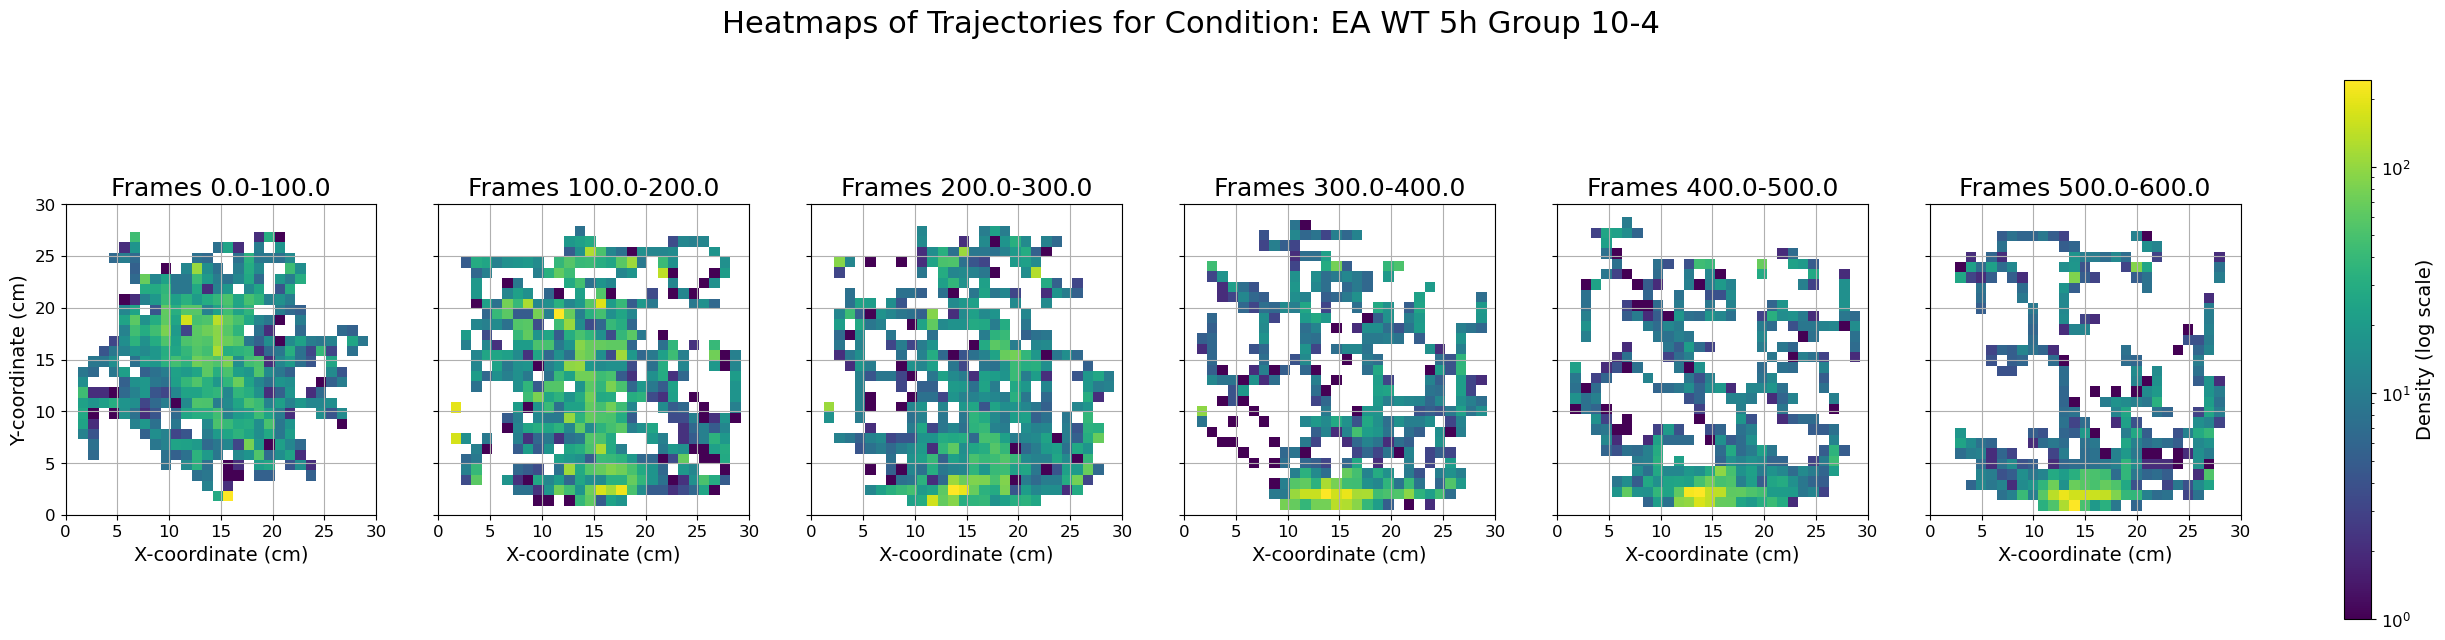

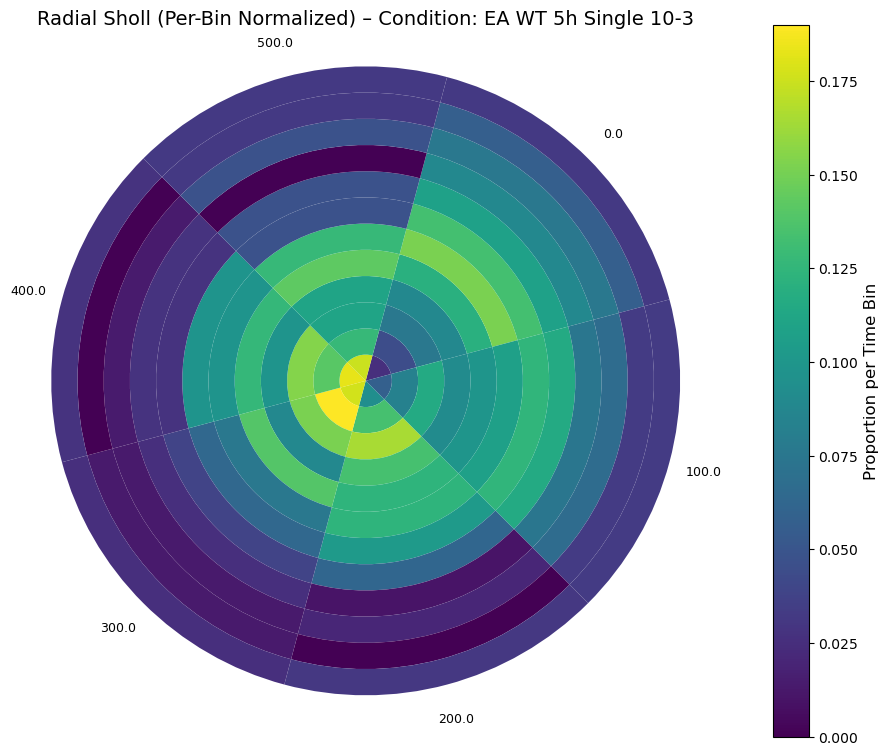

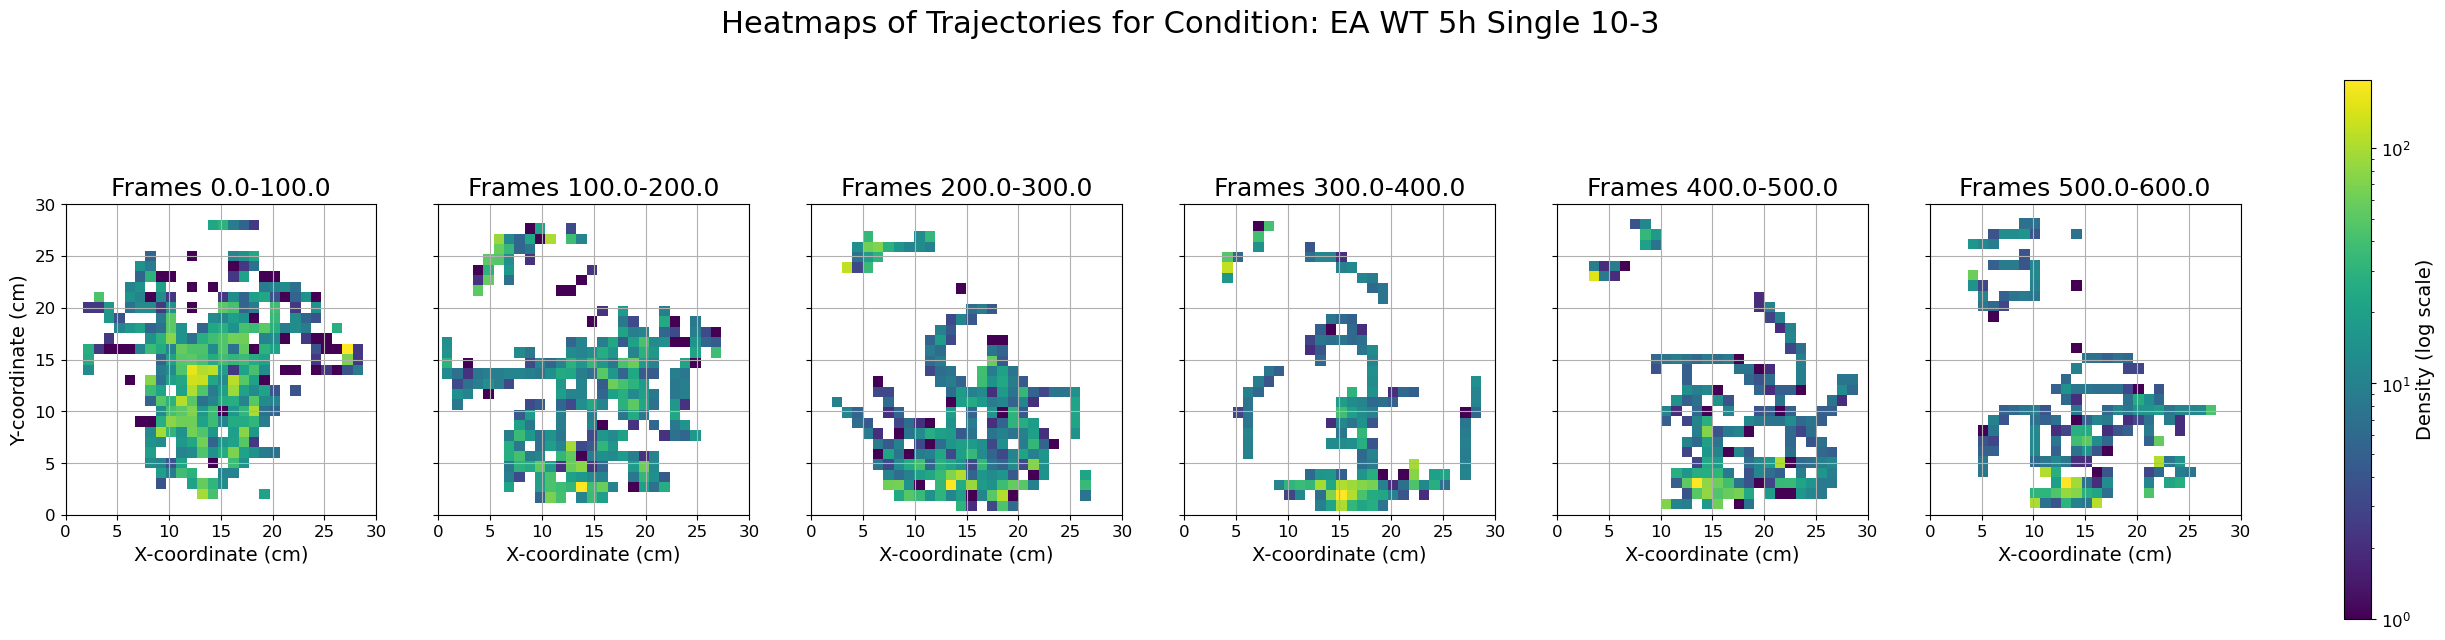

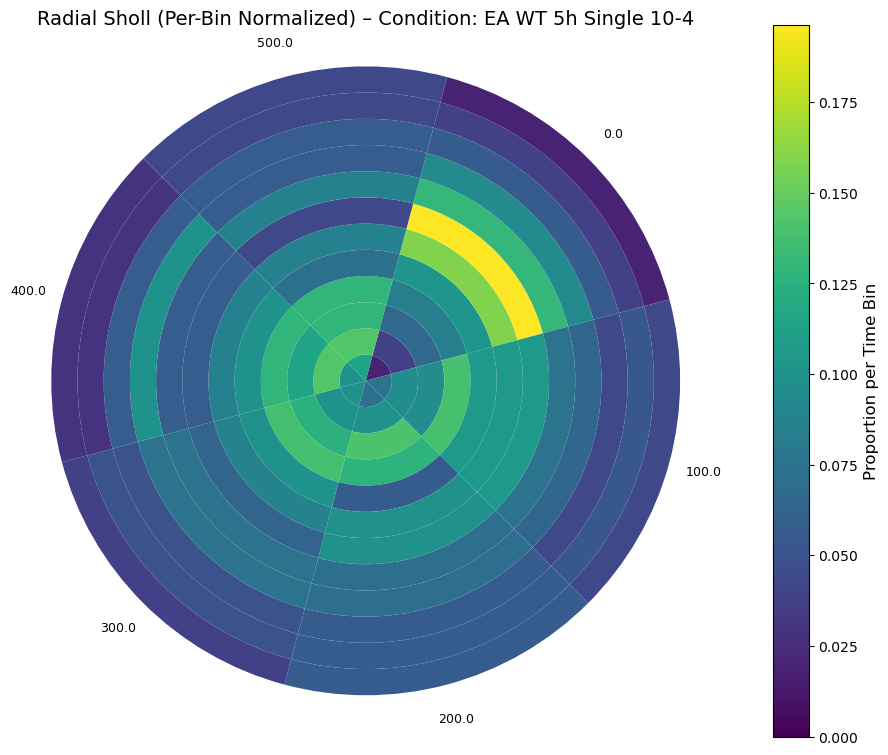

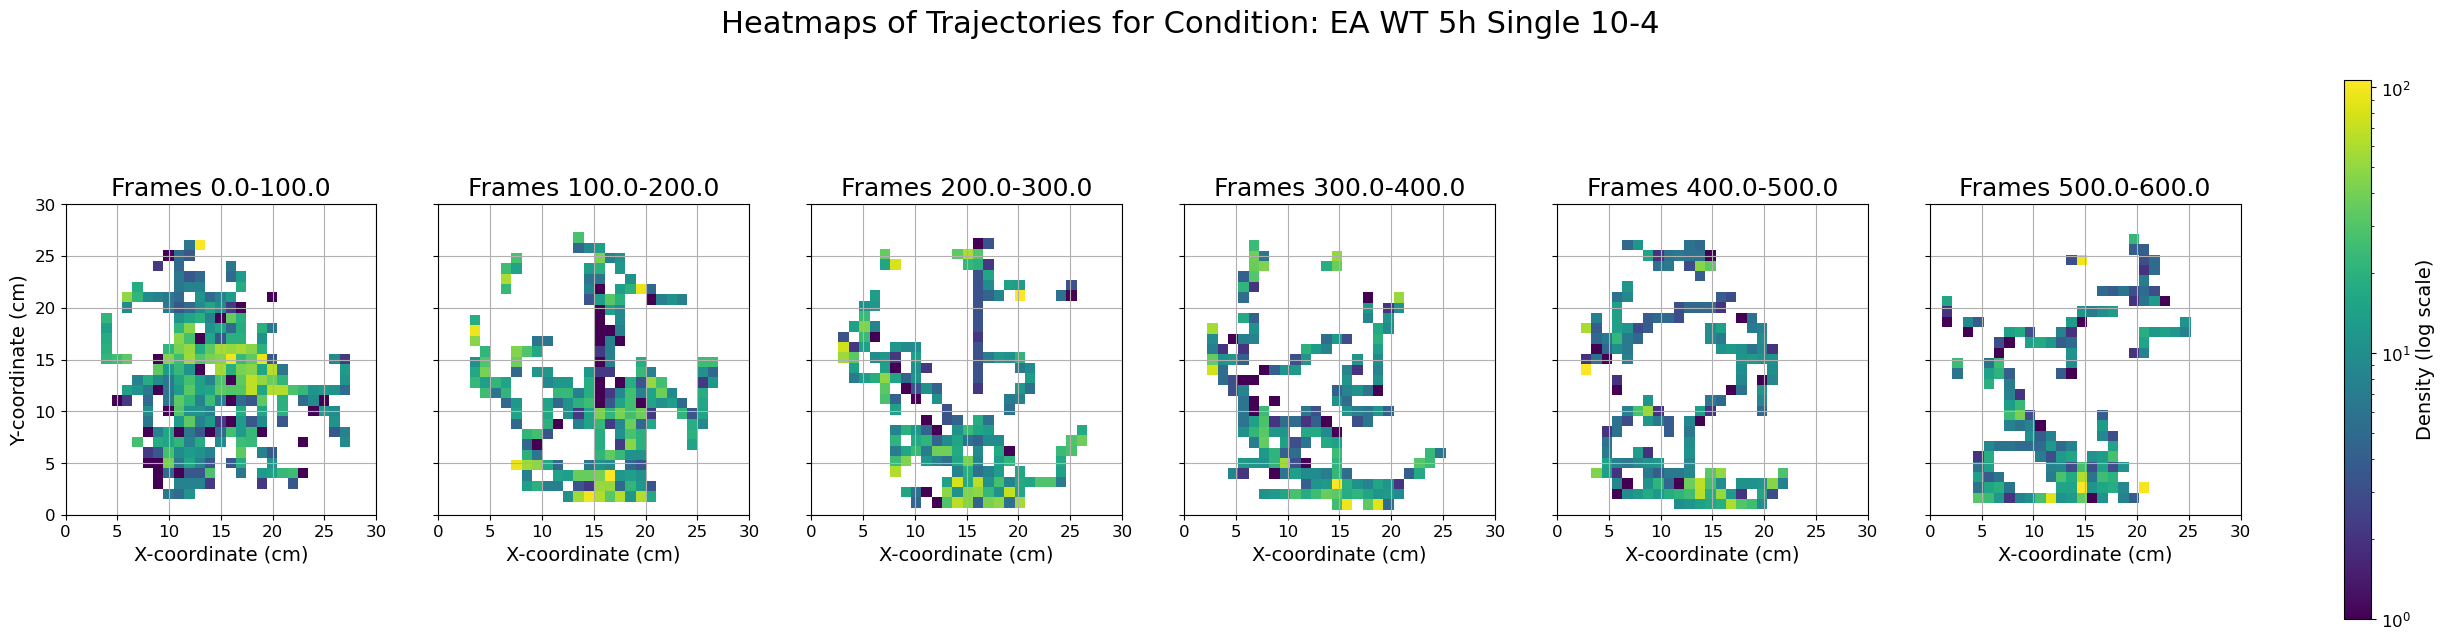

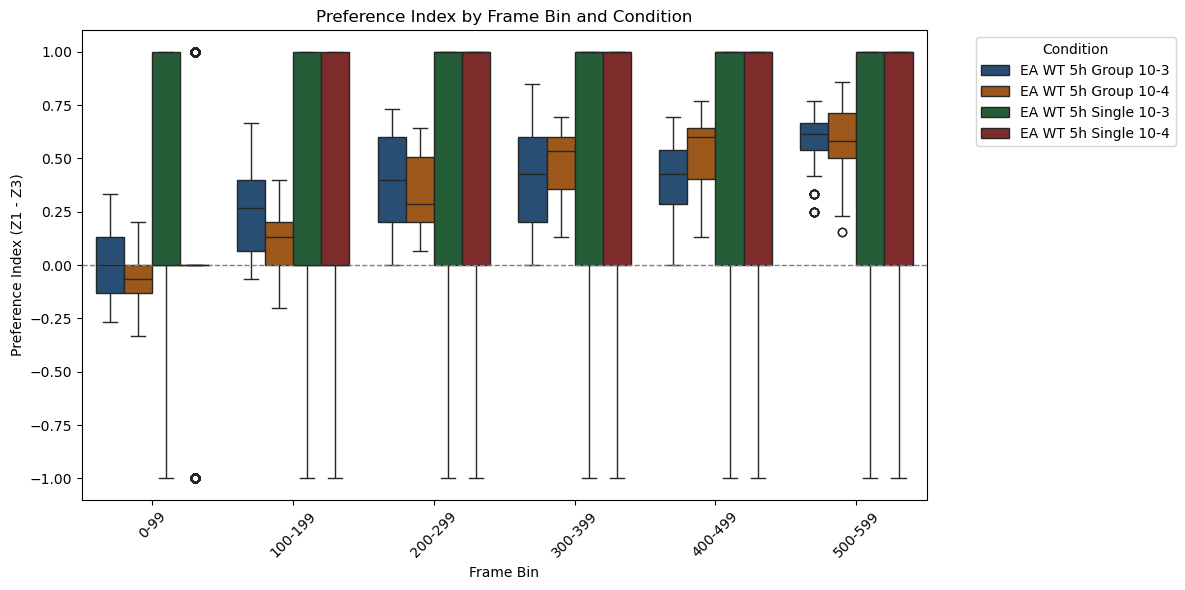

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:1537: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


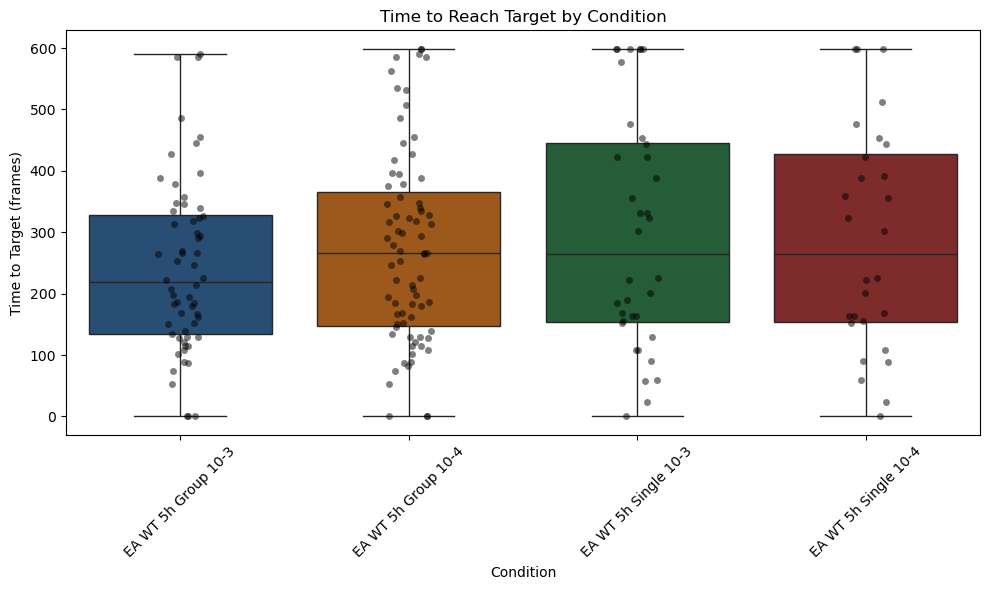

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:1572: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


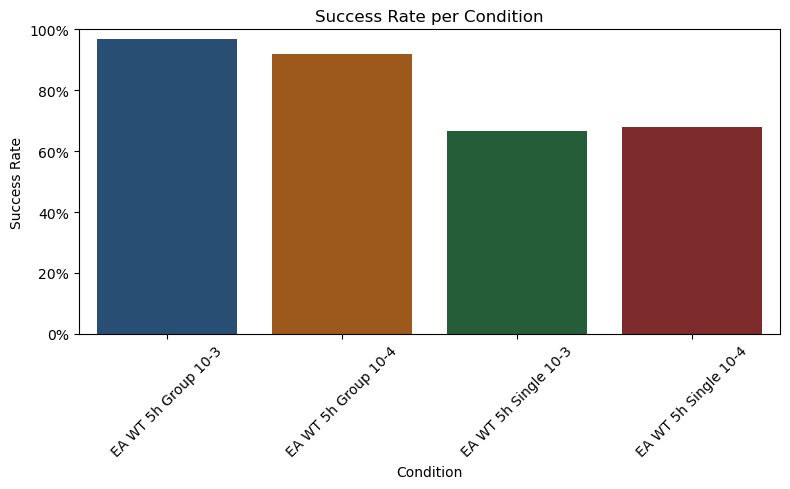

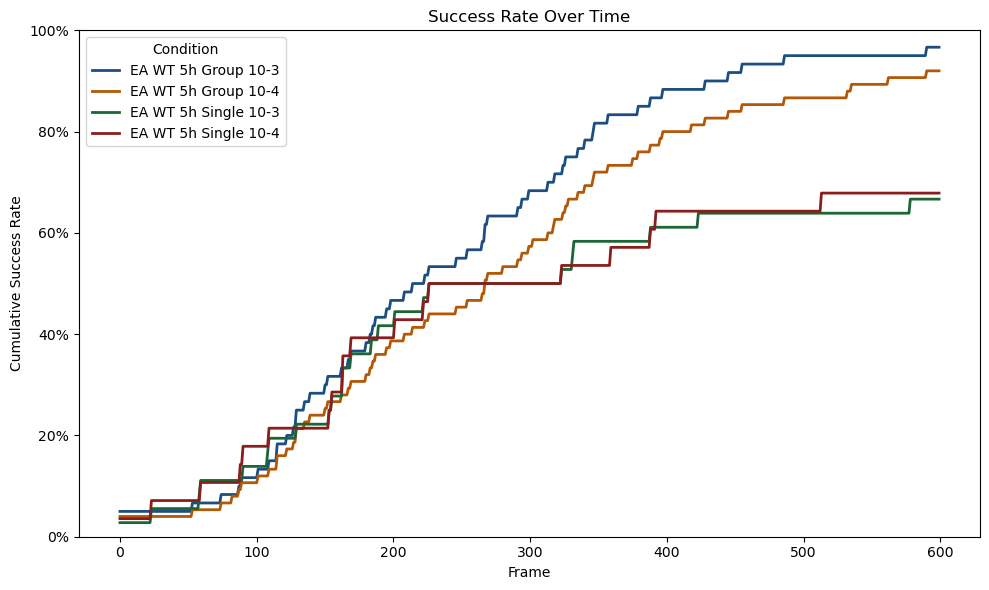

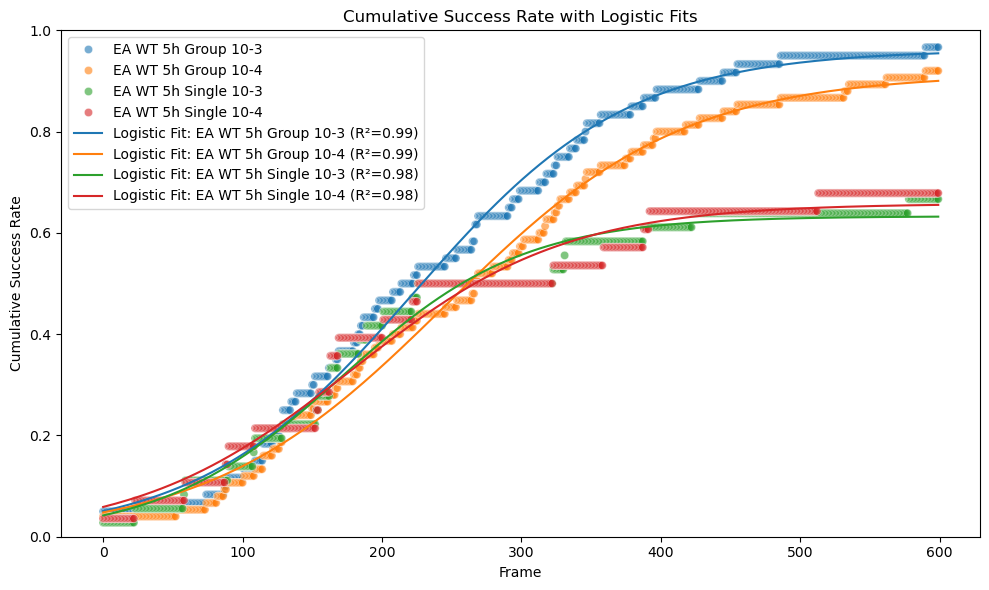

,Condition,L,k,x0,R2
0,EA WT 5h Group 10-3,0.961795,0.012994,222.584631,0.994360
1,EA WT 5h Group 10-4,0.914296,0.011771,245.736974,0.994587
2,EA WT 5h Single 10-3,0.632934,0.015429,171.235563,0.984243
3,EA WT 5h Single 10-4,0.657998,0.013035,178.097586,0.976500


In [7]:
# #Replace the RHS with whichever dataframe you would like to plot.
frame_df = primary_df_interp[primary_df_interp['Starvation'] == '5h']
df_plotter = frame_df

# #Comment or uncomment as and when plot is required.

sbs.lineplot(df_plotter, x = 'Frame', y ='Distance', hue = 'Condition')

 # How to use the colour defining feature on all functions:
        # # Using a dict
        # custom_colors = {
        #     "ConditionA": "#1f77b4",  # blue
        #     "ConditionB": "#ff7f0e",  # orange
        #     "ConditionC": "#2ca02c",  # green
        #     "ConditionD": "#d62728"   # red
        # }

        # plot_zone_means_subplot(df, condition_colors=custom_colors)

        # # Or using a list (order = first appearance of conditions in the data)

        # plot_zone_means_subplot(df, condition_colors=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])

plotting.plot_zone_means_subplot(df_plotter, condition_colors=["#1c4e80", "#b35806", "#1a6634", "#8c1d1d"])

plotting.plot_distance_by_condition(df_plotter, condition_colors=["#1c4e80", "#b35806", "#1a6634", "#8c1d1d"])

plotting.plot_preference_index_over_time(df_plotter, condition_colors=["#1c4e80", "#b35806", "#1a6634", "#8c1d1d"])

for cond in df_plotter['Condition'].unique():
    plotting.radial_sholl_heatmap_per_bin_normalized(df_plotter[df_plotter['Condition'] == cond], max_radius=11, spatial_bin=2)
    plotting.plot_trajectory_heatmaps(df_plotter, cond) 

plotting.plot_preference_index_boxplots(df_plotter, condition_colors=["#1c4e80", "#b35806", "#1a6634", "#8c1d1d"])

cumulative_df = plotting.analyze_and_plot_target_acquisition(df_plotter, condition_colors=["#1c4e80", "#b35806", "#1a6634", "#8c1d1d"])

params = plotting.fit_logistic_to_success(cumulative_df)

params

In [49]:
frame_df.Condition.unique()

array(['EA WT 5h Group 10-3', 'EA WT 5h Single 10-3'], dtype=object)

In [51]:
print(frame_df.columns)
print(frame_df["Frame"].min(), frame_df["Frame"].max())
print(sorted(frame_df["Frame"].unique())[:20])  # first 20 frames


Index(['Odour', 'Y', 'X', 'Speed', 'VY', 'Frame', 'Trial', 'Condition',
       'Genotype', 'Starvation', 'Collective', 'Concentration', 'Individual',
       'Distance', 'Preference Index'],
      dtype='object')
0.0 599.0
[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0]


posx and posy should be finite values
posx and posy should be finite values


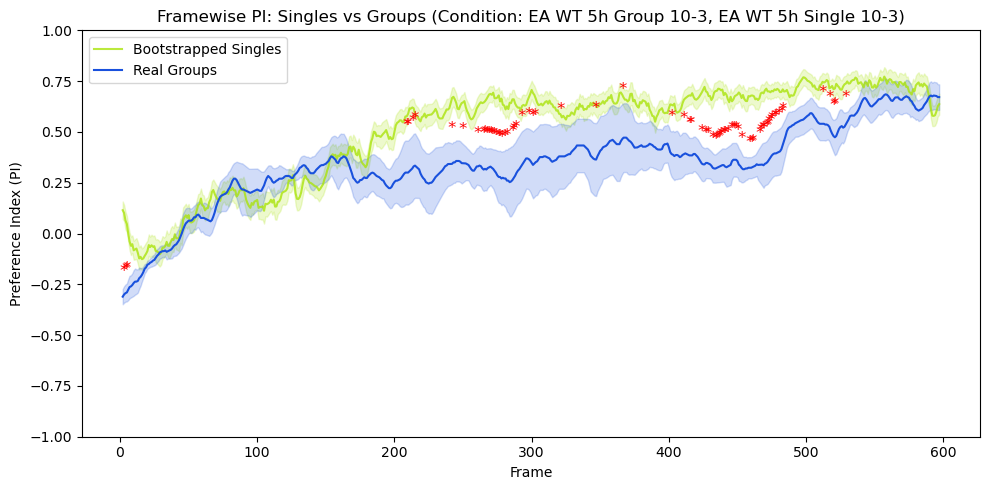

{'frames': [0.0,
  1.0,
  2.0,
  3.0,
  4.0,
  5.0,
  6.0,
  7.0,
  8.0,
  9.0,
  10.0,
  11.0,
  12.0,
  13.0,
  14.0,
  15.0,
  16.0,
  17.0,
  18.0,
  19.0,
  20.0,
  21.0,
  22.0,
  23.0,
  24.0,
  25.0,
  26.0,
  27.0,
  28.0,
  29.0,
  30.0,
  31.0,
  32.0,
  33.0,
  34.0,
  35.0,
  36.0,
  37.0,
  38.0,
  39.0,
  40.0,
  41.0,
  42.0,
  43.0,
  44.0,
  45.0,
  46.0,
  47.0,
  48.0,
  49.0,
  50.0,
  51.0,
  52.0,
  53.0,
  54.0,
  55.0,
  56.0,
  57.0,
  58.0,
  59.0,
  60.0,
  61.0,
  62.0,
  63.0,
  64.0,
  65.0,
  66.0,
  67.0,
  68.0,
  69.0,
  70.0,
  71.0,
  72.0,
  73.0,
  74.0,
  75.0,
  76.0,
  77.0,
  78.0,
  79.0,
  80.0,
  81.0,
  82.0,
  83.0,
  84.0,
  85.0,
  86.0,
  87.0,
  88.0,
  89.0,
  90.0,
  91.0,
  92.0,
  93.0,
  94.0,
  95.0,
  96.0,
  97.0,
  98.0,
  99.0,
  100.0,
  101.0,
  102.0,
  103.0,
  104.0,
  105.0,
  106.0,
  107.0,
  108.0,
  109.0,
  110.0,
  111.0,
  112.0,
  113.0,
  114.0,
  115.0,
  116.0,
  117.0,
  118.0,
  119.0,
  120.0,
  121.0,
  

In [71]:
frame_df = primary_df_interp[primary_df_interp['Concentration'] == '10-3']
frame_df = frame_df[frame_df['Starvation'] == '5h']

import bootstrapping
#bootstrapping.bootstrap_and_shuffle_pair(frame_df, value_col = 'Y')
bootstrapping.bootstrap_and_shuffle_framewise(frame_df, value_col = 'Y', compute_stats = True)

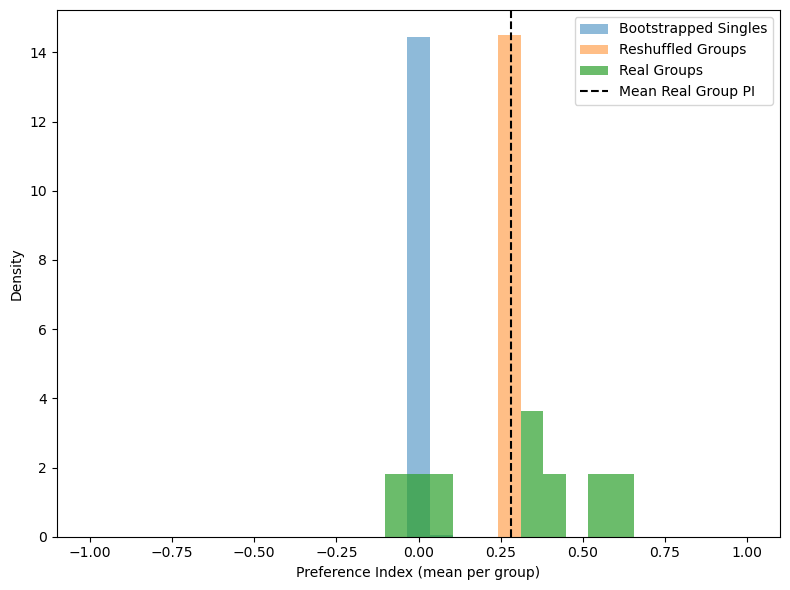

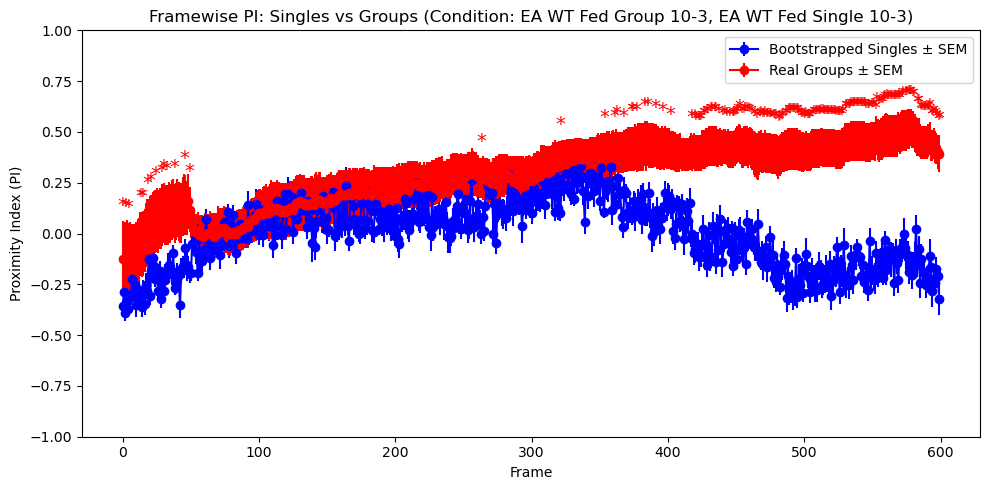

{'frames': [0.0,
  1.0,
  2.0,
  3.0,
  4.0,
  5.0,
  6.0,
  7.0,
  8.0,
  9.0,
  10.0,
  11.0,
  12.0,
  13.0,
  14.0,
  15.0,
  16.0,
  17.0,
  18.0,
  19.0,
  20.0,
  21.0,
  22.0,
  23.0,
  24.0,
  25.0,
  26.0,
  27.0,
  28.0,
  29.0,
  30.0,
  31.0,
  32.0,
  33.0,
  34.0,
  35.0,
  36.0,
  37.0,
  38.0,
  39.0,
  40.0,
  41.0,
  42.0,
  43.0,
  44.0,
  45.0,
  46.0,
  47.0,
  48.0,
  49.0,
  50.0,
  51.0,
  52.0,
  53.0,
  54.0,
  55.0,
  56.0,
  57.0,
  58.0,
  59.0,
  60.0,
  61.0,
  62.0,
  63.0,
  64.0,
  65.0,
  66.0,
  67.0,
  68.0,
  69.0,
  70.0,
  71.0,
  72.0,
  73.0,
  74.0,
  75.0,
  76.0,
  77.0,
  78.0,
  79.0,
  80.0,
  81.0,
  82.0,
  83.0,
  84.0,
  85.0,
  86.0,
  87.0,
  88.0,
  89.0,
  90.0,
  91.0,
  92.0,
  93.0,
  94.0,
  95.0,
  96.0,
  97.0,
  98.0,
  99.0,
  100.0,
  101.0,
  102.0,
  103.0,
  104.0,
  105.0,
  106.0,
  107.0,
  108.0,
  109.0,
  110.0,
  111.0,
  112.0,
  113.0,
  114.0,
  115.0,
  116.0,
  117.0,
  118.0,
  119.0,
  120.0,
  121.0,
  

In [24]:
frame_df = primary_df_interp[primary_df_interp['Concentration'] == '10-3']
frame_df = frame_df[frame_df['Starvation'] == 'Fed']

import bootstrapping
bootstrapping.bootstrap_and_shuffle_pair(frame_df, value_col = 'Y')
bootstrapping.bootstrap_and_shuffle_framewise(frame_df, value_col = 'Y', compute_stats = True)

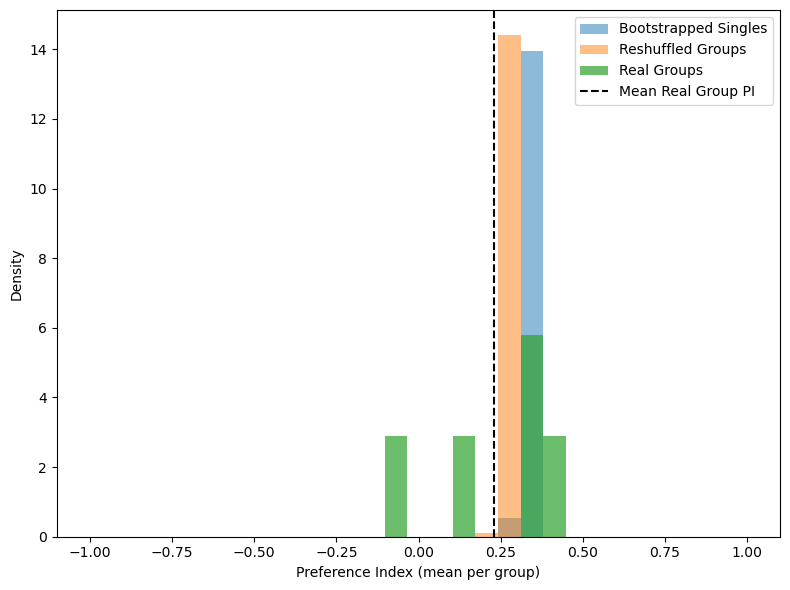

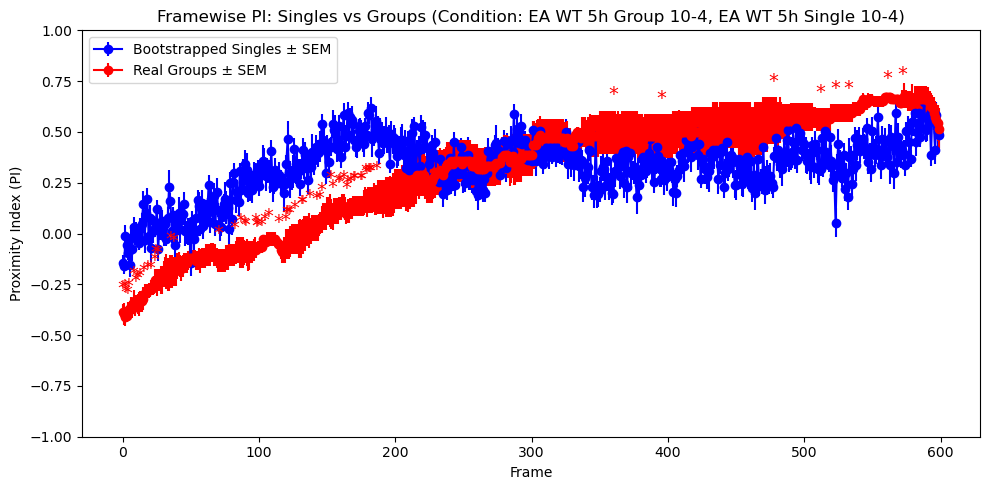

{'frames': [0.0,
  1.0,
  2.0,
  3.0,
  4.0,
  5.0,
  6.0,
  7.0,
  8.0,
  9.0,
  10.0,
  11.0,
  12.0,
  13.0,
  14.0,
  15.0,
  16.0,
  17.0,
  18.0,
  19.0,
  20.0,
  21.0,
  22.0,
  23.0,
  24.0,
  25.0,
  26.0,
  27.0,
  28.0,
  29.0,
  30.0,
  31.0,
  32.0,
  33.0,
  34.0,
  35.0,
  36.0,
  37.0,
  38.0,
  39.0,
  40.0,
  41.0,
  42.0,
  43.0,
  44.0,
  45.0,
  46.0,
  47.0,
  48.0,
  49.0,
  50.0,
  51.0,
  52.0,
  53.0,
  54.0,
  55.0,
  56.0,
  57.0,
  58.0,
  59.0,
  60.0,
  61.0,
  62.0,
  63.0,
  64.0,
  65.0,
  66.0,
  67.0,
  68.0,
  69.0,
  70.0,
  71.0,
  72.0,
  73.0,
  74.0,
  75.0,
  76.0,
  77.0,
  78.0,
  79.0,
  80.0,
  81.0,
  82.0,
  83.0,
  84.0,
  85.0,
  86.0,
  87.0,
  88.0,
  89.0,
  90.0,
  91.0,
  92.0,
  93.0,
  94.0,
  95.0,
  96.0,
  97.0,
  98.0,
  99.0,
  100.0,
  101.0,
  102.0,
  103.0,
  104.0,
  105.0,
  106.0,
  107.0,
  108.0,
  109.0,
  110.0,
  111.0,
  112.0,
  113.0,
  114.0,
  115.0,
  116.0,
  117.0,
  118.0,
  119.0,
  120.0,
  121.0,
  

In [25]:
frame_df = primary_df_interp[primary_df_interp['Concentration'] == '10-4']
frame_df = frame_df[frame_df['Starvation'] == '5h']

import bootstrapping
bootstrapping.bootstrap_and_shuffle_pair(frame_df, value_col = 'Y')
bootstrapping.bootstrap_and_shuffle_framewise(frame_df, value_col = 'Y', compute_stats = True)

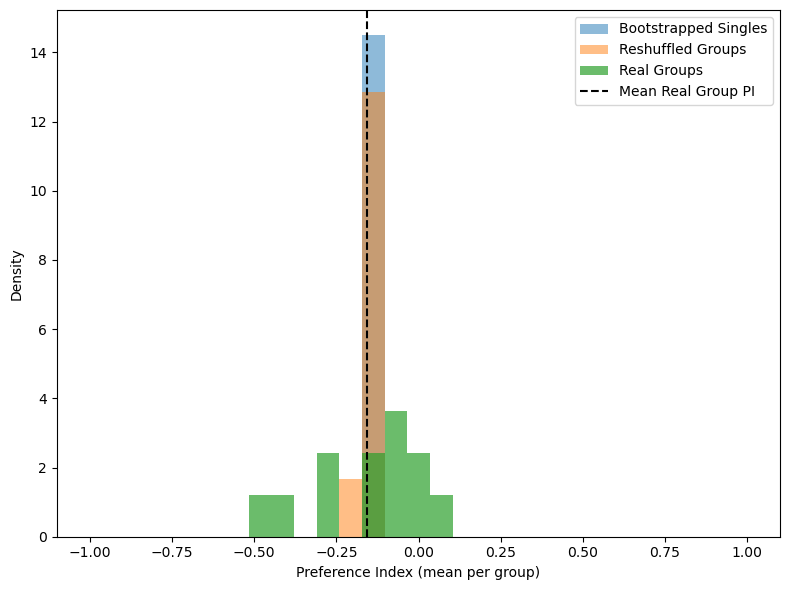

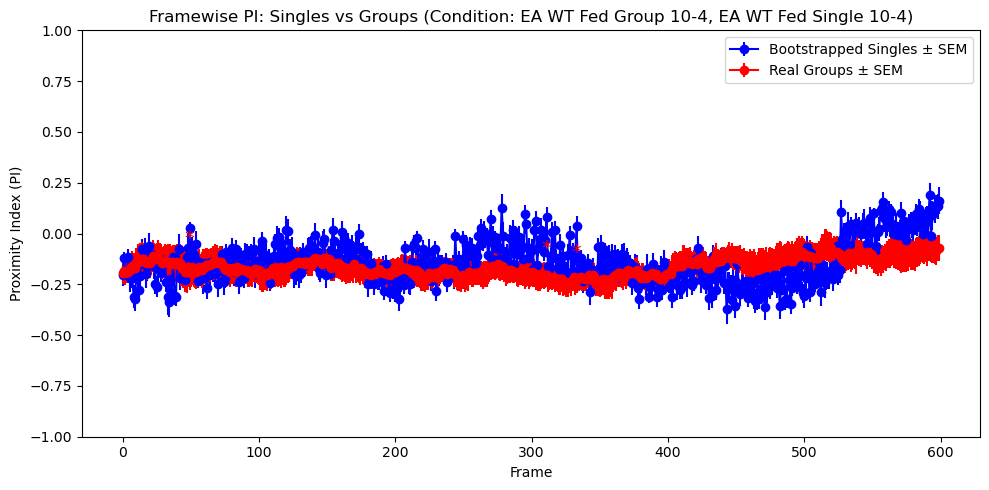

{'frames': [0.0,
  1.0,
  2.0,
  3.0,
  4.0,
  5.0,
  6.0,
  7.0,
  8.0,
  9.0,
  10.0,
  11.0,
  12.0,
  13.0,
  14.0,
  15.0,
  16.0,
  17.0,
  18.0,
  19.0,
  20.0,
  21.0,
  22.0,
  23.0,
  24.0,
  25.0,
  26.0,
  27.0,
  28.0,
  29.0,
  30.0,
  31.0,
  32.0,
  33.0,
  34.0,
  35.0,
  36.0,
  37.0,
  38.0,
  39.0,
  40.0,
  41.0,
  42.0,
  43.0,
  44.0,
  45.0,
  46.0,
  47.0,
  48.0,
  49.0,
  50.0,
  51.0,
  52.0,
  53.0,
  54.0,
  55.0,
  56.0,
  57.0,
  58.0,
  59.0,
  60.0,
  61.0,
  62.0,
  63.0,
  64.0,
  65.0,
  66.0,
  67.0,
  68.0,
  69.0,
  70.0,
  71.0,
  72.0,
  73.0,
  74.0,
  75.0,
  76.0,
  77.0,
  78.0,
  79.0,
  80.0,
  81.0,
  82.0,
  83.0,
  84.0,
  85.0,
  86.0,
  87.0,
  88.0,
  89.0,
  90.0,
  91.0,
  92.0,
  93.0,
  94.0,
  95.0,
  96.0,
  97.0,
  98.0,
  99.0,
  100.0,
  101.0,
  102.0,
  103.0,
  104.0,
  105.0,
  106.0,
  107.0,
  108.0,
  109.0,
  110.0,
  111.0,
  112.0,
  113.0,
  114.0,
  115.0,
  116.0,
  117.0,
  118.0,
  119.0,
  120.0,
  121.0,
  

In [26]:
frame_df = primary_df_interp[primary_df_interp['Concentration'] == '10-4']
frame_df = frame_df[frame_df['Starvation'] == 'Fed']

import bootstrapping
bootstrapping.bootstrap_and_shuffle_pair(frame_df, value_col = 'Y')
bootstrapping.bootstrap_and_shuffle_framewise(frame_df, value_col = 'Y', compute_stats = True)

In [ ]:
plotting.plot_zone_1_over_time(df_plotter)

In [ ]:
# stat_analysis.analyze_two_way_anova(df_TNTx5HT7_EA_103[df_TNTx5HT7_EA_103['Frame'] > 400])

In [ ]:
# # Replace df_TNTx5HT7_EA_105 with whichever df speed you would like to analyze.

# speed_analysis_df = df_TNTx5HT7_EA_103
# speed_analysis_df = speed_analysis_df[speed_analysis_df['Speed'] < 2.0]
# speed_analysis_df = speed_analysis_df[speed_analysis_df['Speed'] > 0.5]

In [ ]:
# stat_analysis.analyze_two_way_anova(speed_analysis_df, value_col='Speed', trial_averages=True)

In [ ]:
# # Replace df with your df for analysis

# tukey_result, tukey_summary = stat_analysis.run_tukey_posthoc(
#     df=df_TNTx5HT7_EA_103,
#     value_col='Speed',
#     factor_a='Genotype',
#     factor_b='Starvation',
#     min_val=0.5,
#     max_val=2.0,
#     alpha=0.05
# )
# print(tukey_summary)

In [ ]:
# stat_analysis.analyze_two_way_anova(df_TNTx5HT7_EA_105[df_TNTx5HT7_EA_105['Frame'] > 400])

In [ ]:
# df_TNTxuPN_EA_105

In [ ]:
# df_stats = df_TNTxuPN_EA_105

# df_stats_PI = df_stats[(df_stats['Frame']>400) & (df_stats['Frame']<600) ]
# df_stats_speed = df_stats[(df_stats['Speed'] >= 0.5) & (df_stats['Speed'] <= 2)]

# # plotting.plot_preference_index_boxplots(df_stats, bin_size=200)
# # plotting.plot_preference_index_over_time(df_stats)

# stat_analysis.analyze_two_way_anova(
#     df_stats_PI,
#    factor_a='Genotype',
#    factor_b='Starvation',
#     value_col='Preference Index',
#     alpha=0.05,
#     verbose=True,
#     trial_averages=True,
#     group_cols=['Starvation', 'Trial', 'Genotype'],  # Customizable if needed
#     return_data = True
# )



# print('-----------------------------------------------------')
# stat_analysis.run_tukey_posthoc(
#    df_stats_PI,
#     'Preference Index',
#     'Genotype',
#     'Starvation',
#     min_val=None,
#     max_val=None,
#     alpha=0.05,
#     trial_averages=True,
#     group_cols=['Starvation', 'Trial', 'Genotype'],  # Customizable if needed
# )



In [ ]:
# sbs.barplot(data=df_stats_PI[df_stats_PI['Frame'] > 400], x = 'Condition', y='Preference Index')
# plt.xticks(rotation = 45)